# Daily Closeout

Cierre ejecutivo de `daily` sobre el run full `v030`, separando `schema`, residuo `vw` explicable y n?cleo duro real.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import clear_output, display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 220)

ROOT = Path(r'C:/TSIS_Data/01_TSIS_backtest_SmallCaps')
RUN_DIR = ROOT / 'runs/backtest/daily_v2_validation/daily_validate_2005_2026_d_full_v030'
CURRENT_PATH = RUN_DIR / 'daily_current.parquet'
LT1B_PATH = ROOT / 'runs/backtest/market_cap_last_observed_cutoff/20260320_market_cap_last_observed_cutoff/market_cap_cutoff_lt_1b_active_inactive.parquet'
VALIDATION_MANIFEST = json.loads((RUN_DIR / 'validation_run_manifest.json').read_text(encoding='utf-8'))
MATERIALIZATION_SUMMARY = json.loads((RUN_DIR / 'materialization_summary.json').read_text(encoding='utf-8'))
LT1B_TICKERS = set(pd.read_parquet(LT1B_PATH, columns=['ticker'])['ticker'].astype(str).str.upper().unique().tolist())

def load_current() -> pd.DataFrame:
    df = pd.read_parquet(CURRENT_PATH)
    df['ticker'] = df['ticker'].astype(str).str.upper()
    df = df[df['ticker'].isin(LT1B_TICKERS)].copy()
    metrics = pd.json_normalize(df['metrics_json'].map(json.loads))
    out = pd.concat([df.drop(columns=['metrics_json']).reset_index(drop=True), metrics.reset_index(drop=True)], axis=1)
    out['issues_str'] = out['issues'].astype(str)
    out['warns_str'] = out['warns'].astype(str)
    out['has_vw_issue'] = out['issues_str'].str.contains('vw_outside_range_severe', na=False)
    out['has_vw_warn'] = out['warns_str'].str.contains('vw_outside_range_', na=False)
    out['has_invalid_price_issue'] = out['issues_str'].str.contains('negative_or_zero_ohlc_rows', na=False)
    out['has_parse_issue'] = out['issues_str'].str.contains('all_rows_invalid_after_parse', na=False)
    out['vw_ratio_pct'] = np.where(out['rows_after_parse'] > 0, out['vw_outside_range_rows'] / out['rows_after_parse'] * 100.0, np.nan)
    out['n_per_day'] = np.where(out['rows_after_parse'] > 0, out['n_sum'] / out['rows_after_parse'], np.nan)
    out['v_per_day'] = np.where(out['rows_after_parse'] > 0, out['v_sum'] / out['rows_after_parse'], np.nan)
    out['daily_refined_bucket'] = np.select([
        out['has_parse_issue'] | out['has_invalid_price_issue'],
        out['has_vw_issue'] & (out['vw_ratio_pct'] < 1.0) & (out['vw_problem_days'] < 3),
        out['has_vw_issue'] & (out['vw_ratio_pct'] < 5.0) & (out['vw_problem_days'] < 10),
        out['has_vw_issue'] & (out['vw_ratio_pct'] >= 5.0) & (out['vw_ratio_pct'] < 20.0),
        out['has_vw_issue'] & (out['vw_ratio_pct'] >= 20.0),
        out['has_vw_warn'],
    ], [
        'hard_invalid_parse_or_price',
        'vw_edge_absmax_only',
        'vw_low_ratio_limited_days',
        'vw_mid_ratio_illiquid_regime',
        'vw_high_ratio_illiquid_regime',
        'vw_warn_minor_or_material',
    ], default='schema_only_or_other')
    out['quality_policy'] = np.select([
        out['daily_refined_bucket'].isin(['schema_only_or_other', 'vw_edge_absmax_only']),
        out['daily_refined_bucket'].isin(['vw_low_ratio_limited_days', 'vw_mid_ratio_illiquid_regime', 'vw_high_ratio_illiquid_regime', 'vw_warn_minor_or_material']),
        out['daily_refined_bucket'].eq('hard_invalid_parse_or_price'),
    ], ['good', 'review', 'bad'], default='review')
    return out

cur = load_current()


## Preflight


In [2]:
selected_files_full = int(sum(batch.get('files_selected', batch.get('rows', 0)) for batch in VALIDATION_MANIFEST.get('batch_files', [])))
preflight = pd.DataFrame([{
    'current_path': str(CURRENT_PATH),
    'scope': '<1B filtered from full v030',
    'selected_files_full': selected_files_full,
    'current_rows_full': MATERIALIZATION_SUMMARY['current_rows'],
    'rows_lt1b': int(len(cur)),
    'tickers_lt1b': int(cur['ticker'].nunique()),
    'validator_version': VALIDATION_MANIFEST['validator_version'],
    'workers': VALIDATION_MANIFEST['workers'],
    'finished_at_utc': MATERIALIZATION_SUMMARY['materialized_at_utc'],
}])
display(preflight)


,current_path,scope,selected_files_full,current_rows_full,rows_lt1b,tickers_lt1b,validator_version,workers,finished_at_utc
0,C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\b...,<1B filtered from full v030,125438,125438,44423,4824,daily_v2_validate_file/0.3.0,8,2026-04-05T07:09:50.628712+00:00


## Snapshot


,files_total,tickers_total,hard_fail_files,soft_fail_files,vw_issue_files,invalid_parse_or_price_files
0,44423,4824,9475,34948,9427,102


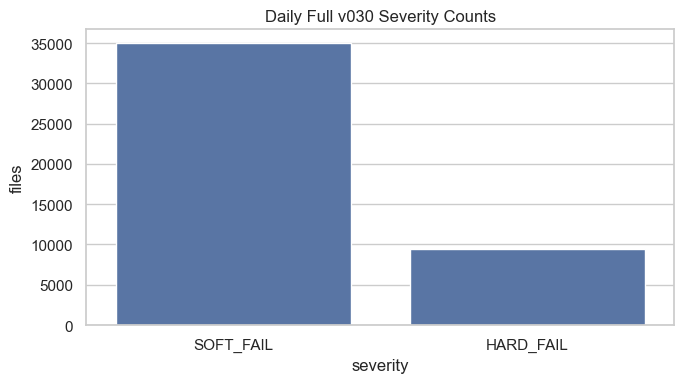

In [3]:
snapshot = pd.DataFrame([{
    'files_total': int(len(cur)),
    'tickers_total': int(cur['ticker'].nunique()),
    'hard_fail_files': int((cur['severity'] == 'HARD_FAIL').sum()),
    'soft_fail_files': int((cur['severity'] == 'SOFT_FAIL').sum()),
    'vw_issue_files': int(cur['has_vw_issue'].sum()),
    'invalid_parse_or_price_files': int((cur['has_parse_issue'] | cur['has_invalid_price_issue']).sum()),
}])
display(snapshot)

severity = cur['severity'].value_counts().rename_axis('severity').reset_index(name='files')
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=severity, x='severity', y='files', ax=ax)
ax.set_title('Daily Full v030 Severity Counts')
plt.tight_layout()


## Buckets Refinados


,daily_refined_bucket,files,tickers,median_ratio_pct,median_problem_days,median_pct_of_vw,median_n_per_day,median_v_per_day,pct_of_total
1,schema_only_or_other,26520,3992,0.000000,0.0,0.377930,1187.641492,115452.384139,59.698805
6,vw_warn_minor_or_material,8890,3470,0.800000,2.0,0.312448,191.128480,35299.850460,20.012156
2,vw_edge_absmax_only,2854,1628,0.400000,1.0,7.513898,1875.028479,82410.006480,6.424600
5,vw_mid_ratio_illiquid_regime,2719,1367,10.370370,21.0,0.140053,62.880682,12771.933884,6.120703
4,vw_low_ratio_limited_days,2352,1404,1.984127,4.0,4.527275,2230.891429,120633.003974,5.294555
3,vw_high_ratio_illiquid_regime,986,501,26.315789,46.0,0.134466,29.897383,3928.321810,2.219571
0,hard_invalid_parse_or_price,102,54,2.358491,2.0,18.989547,6.590909,16595.900000,0.229611


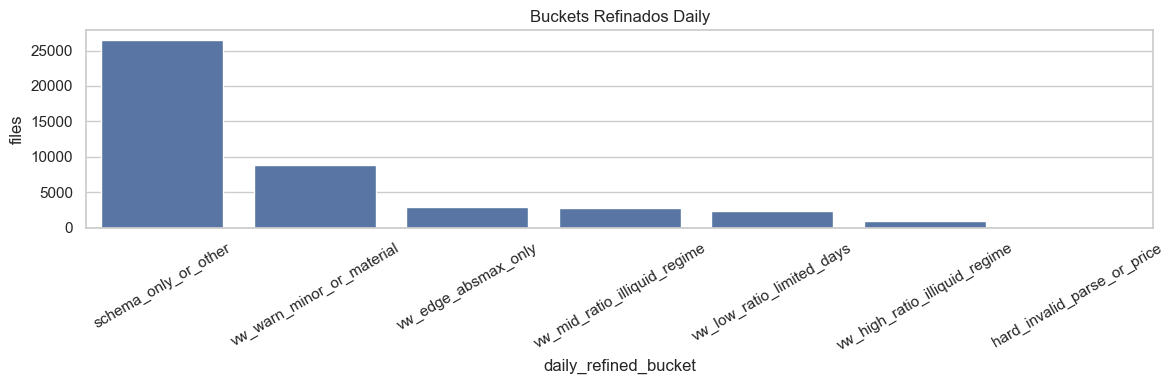

In [4]:
bucket_summary = cur.groupby('daily_refined_bucket').agg(
    files=('ticker', 'size'),
    tickers=('ticker', 'nunique'),
    median_ratio_pct=('vw_ratio_pct', 'median'),
    median_problem_days=('vw_problem_days', 'median'),
    median_pct_of_vw=('vw_outside_range_pct_of_vw_median', 'median'),
    median_n_per_day=('n_per_day', 'median'),
    median_v_per_day=('v_per_day', 'median'),
).reset_index().sort_values('files', ascending=False)
bucket_summary['pct_of_total'] = bucket_summary['files'] / len(cur) * 100.0
display(bucket_summary)

fig, ax = plt.subplots(figsize=(12,4))
sns.barplot(data=bucket_summary, x='daily_refined_bucket', y='files', ax=ax, order=bucket_summary['daily_refined_bucket'])
ax.set_title('Buckets Refinados Daily')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()


## Lectura Ejecutiva


In [5]:
executive = pd.DataFrame([
    {'claim': 'schema es conocido y transversal', 'value': int(cur['warns_str'].str.contains('dataset_read_incompatible_schema', na=False).sum())},
    {'claim': 'severe actual por borde abs_max', 'value': int(((cur['daily_refined_bucket'] == 'vw_edge_absmax_only')).sum())},
    {'claim': 'severe persistente iliquido', 'value': int((cur['daily_refined_bucket'] == 'vw_high_ratio_illiquid_regime').sum())},
    {'claim': 'hard invalid parse/precio', 'value': int((cur['daily_refined_bucket'] == 'hard_invalid_parse_or_price').sum())},
])
display(executive)


,claim,value
0,schema es conocido y transversal,44423
1,severe actual por borde abs_max,2854
2,severe persistente iliquido,986
3,hard invalid parse/precio,102


## Pol?tica Good Review Bad


In [6]:
policy = pd.DataFrame([
    {'bucket': 'schema_only_or_other', 'policy': 'good', 'reason': 'schema known, no economic issue'},
    {'bucket': 'vw_edge_absmax_only', 'policy': 'good', 'reason': '1-2 days, edge abs gap, not persistent'},
    {'bucket': 'vw_warn_minor_or_material', 'policy': 'review', 'reason': 'vw mismatch present but below hard bucket'},
    {'bucket': 'vw_low_ratio_limited_days', 'policy': 'review', 'reason': 'few affected days, limited ratio'},
    {'bucket': 'vw_mid_ratio_illiquid_regime', 'policy': 'review', 'reason': 'persistent but typically illiquid flat-bar regime'},
    {'bucket': 'vw_high_ratio_illiquid_regime', 'policy': 'review', 'reason': 'stronger illiquid regime, keep out of core until use-case review'},
    {'bucket': 'hard_invalid_parse_or_price', 'policy': 'bad', 'reason': 'true hard invalid parse or non-positive OHLC'},
])
display(policy)


,bucket,policy,reason
0,schema_only_or_other,good,"schema known, no economic issue"
1,vw_edge_absmax_only,good,"1-2 days, edge abs gap, not persistent"
2,vw_warn_minor_or_material,review,vw mismatch present but below hard bucket
3,vw_low_ratio_limited_days,review,"few affected days, limited ratio"
4,vw_mid_ratio_illiquid_regime,review,persistent but typically illiquid flat-bar regime
5,vw_high_ratio_illiquid_regime,review,"stronger illiquid regime, keep out of core unt..."
6,hard_invalid_parse_or_price,bad,true hard invalid parse or non-positive OHLC


## Casos Duros Reales


In [7]:
hard_invalid = cur[cur['daily_refined_bucket'] == 'hard_invalid_parse_or_price'].copy()
cols = ['ticker','year','file','issues','rows_after_parse','negative_or_zero_ohlc_rows','o_min','l_min','h_max','c_max']
display(hard_invalid[cols].head(40))


,ticker,year,file,issues,rows_after_parse,negative_or_zero_ohlc_rows,o_min,l_min,h_max,c_max
4,AAGR,2024,D:\ohlcv_daily\ticker=AAGR\year=2024\day_aggs_...,"[""negative_or_zero_ohlc_rows"", ""vw_outside_ran...",235.0,5.0,0.0000,0.0,1.2200,1.1700
5,AAGR,2025,D:\ohlcv_daily\ticker=AAGR\year=2025\day_aggs_...,"[""negative_or_zero_ohlc_rows"", ""vw_outside_ran...",207.0,26.0,0.0000,0.0,0.0199,0.0199
6,AAGR,2026,D:\ohlcv_daily\ticker=AAGR\year=2026\day_aggs_...,"[""negative_or_zero_ohlc_rows"", ""vw_outside_ran...",36.0,1.0,0.0090,0.0,0.0099,0.0099
930,AFIB,2025,D:\ohlcv_daily\ticker=AFIB\year=2025\day_aggs_...,"[""negative_or_zero_ohlc_rows"", ""vw_outside_ran...",207.0,1.0,0.0001,0.0,0.0790,0.0700
1637,ALPP,2025,D:\ohlcv_daily\ticker=ALPP\year=2025\day_aggs_...,"[""negative_or_zero_ohlc_rows"", ""vw_outside_ran...",239.0,3.0,0.0000,0.0,0.0294,0.0200
2229,ANTH,2021,D:\ohlcv_daily\ticker=ANTH\year=2021\day_aggs_...,"[""negative_or_zero_ohlc_rows""]",1.0,1.0,0.0000,0.0,0.0011,0.0000
2231,ANTH,2023,D:\ohlcv_daily\ticker=ANTH\year=2023\day_aggs_...,"[""negative_or_zero_ohlc_rows""]",38.0,1.0,0.0000,0.0,0.0001,0.0001
2232,ANTH,2024,D:\ohlcv_daily\ticker=ANTH\year=2024\day_aggs_...,"[""negative_or_zero_ohlc_rows""]",12.0,2.0,0.0001,0.0,0.0002,0.0002
2233,ANTH,2025,D:\ohlcv_daily\ticker=ANTH\year=2025\day_aggs_...,"[""negative_or_zero_ohlc_rows""]",37.0,1.0,0.0001,0.0,0.0010,0.0010
2796,ARDS,2024,D:\ohlcv_daily\ticker=ARDS\year=2024\day_aggs_...,"[""negative_or_zero_ohlc_rows""]",171.0,4.0,0.0000,0.0,0.0930,0.0895


## Inspector Final


In [8]:
inspect_df = cur[cur['daily_refined_bucket'].isin(['vw_edge_absmax_only','vw_low_ratio_limited_days','vw_mid_ratio_illiquid_regime','vw_high_ratio_illiquid_regime','hard_invalid_parse_or_price'])].copy()
inspect_df = inspect_df.sort_values(['daily_refined_bucket','vw_ratio_pct','vw_outside_range_abs_max'], ascending=[True, False, False])
bucket_dd = widgets.Dropdown(options=sorted(inspect_df['daily_refined_bucket'].dropna().unique().tolist()), description='bucket', layout=widgets.Layout(width='320px'))
file_dd = widgets.Dropdown(description='file', layout=widgets.Layout(width='900px'))
out = widgets.Output()

def refresh_files(*_):
    sub = inspect_df[inspect_df['daily_refined_bucket'] == bucket_dd.value].copy()
    opts = []
    for idx, row in sub.head(250).iterrows():
        label = f"{row['ticker']} | {int(row['year'])} | ratio={row.get('vw_ratio_pct', np.nan):.2f}% | abs_max={row.get('vw_outside_range_abs_max', np.nan):.4f}"
        opts.append((label, idx))
    file_dd.options = opts
    if opts: file_dd.value = opts[0][1]

def render(*_):
    with out:
        clear_output(wait=True)
        if file_dd.value is None:
            print('sin casos')
            return
        row = inspect_df.loc[file_dd.value]
        display(row[['ticker','year','daily_refined_bucket','quality_policy','issues','warns','rows_after_parse','vw_outside_range_rows','vw_problem_days','vw_ratio_pct','vw_outside_range_abs_max','vw_outside_range_pct_of_vw_max','n_per_day','v_per_day','coverage_ratio_vs_business_days','file']].to_frame().T)

bucket_dd.observe(refresh_files, names='value')
file_dd.observe(render, names='value')
refresh_files()
render()
display(widgets.VBox([widgets.HBox([bucket_dd]), file_dd, out]))


In [ ]:
import sys
from pathlib import Path
import importlib

import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

PROJECT_ROOT = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.inspection.daily.daily_case_panel as daily_case_panel
importlib.reload(daily_case_panel)

from scripts.inspection.daily.daily_case_panel import (
    build_daily_case_selector,
    export_daily_case_samples,
)

if "cur" not in globals():
    raise RuntimeError(
        "No existe `cur` en el notebook. Ejecuta antes las celdas que construyen el dataframe operativo de daily."
    )

GOOD_BUCKETS = [
    "schema_only_or_other",
    "vw_edge_absmax_only",
]

SCOPE_CONFIG = {
    "bad": {
        "mode": "hard_invalid",
        "buckets": None,
        "export_folder": "hard_invalid",
        "cases_per_bucket": 12,
        "title": "Bad | hard_invalid | exporta todos",
    },
    "non_good_quality": {
        "mode": "non_good_quality",
        "buckets": None,
        "export_folder": "non_good_quality",
        "cases_per_bucket": 12,
        "title": "Non Good Quality | excluye hard_invalid",
    },
    "good": {
        "mode": None,
        "buckets": GOOD_BUCKETS,
        "export_folder": "good_sample",
        "cases_per_bucket": 12,
        "title": "Good | muestra representativa",
    },
}

scope_dd = widgets.Dropdown(
    options=["bad", "non_good_quality", "good"],
    value="bad",
    description="scope",
    layout=widgets.Layout(width="340px"),
)

export_btn = widgets.Button(
    description="Exportar scope",
    button_style="primary",
    layout=widgets.Layout(width="180px"),
)

status_out = widgets.Output()
selector_out = widgets.Output()


def render_scope(*_):
    cfg = SCOPE_CONFIG[scope_dd.value]
    with selector_out:
        clear_output(wait=True)
        display(Markdown(f"## Daily inspection | {cfg['title']}"))

        if scope_dd.value == "bad":
            display(Markdown(
                "- `bad` = solo `hard_invalid_parse_or_price`\n"
                "- se usa para el dossier `bad_case_evidence_packs`\n"
                "- la exportacion reemplaza lo anterior en esa carpeta"
            ))
        elif scope_dd.value == "non_good_quality":
            display(Markdown(
                "- `non_good_quality` = casos no `good` y no `bad`\n"
                "- incluye franja contractual `recoverable_with_flag`\n"
                "- excluye explicitamente `hard_invalid_parse_or_price`\n"
                "- se usa para `flagged_case_evidence_packs`"
            ))
        else:
            display(Markdown(
                "- `good` = muestra representativa de buckets buenos\n"
                "- se usa para `good_justification`\n"
                "- no exporta todo el universo good, solo muestra"
            ))

        if cfg["mode"] is not None:
            display(
                build_daily_case_selector(
                    cur,
                    mode=cfg["mode"],
                    top_n=250,
                )
            )
        else:
            display(
                build_daily_case_selector(
                    cur,
                    buckets=cfg["buckets"],
                    top_n=250,
                )
            )


def export_scope(_):
    cfg = SCOPE_CONFIG[scope_dd.value]
    output_dir = (
        PROJECT_ROOT
        / "01_foundations"
        / "inspection_dossiers"
        / "daily"
        / "evidence_assets"
        / cfg["export_folder"]
    )

    with status_out:
        clear_output(wait=True)
        display(Markdown(f"## Exportando | {cfg['title']}"))

        kwargs = dict(
            cur=cur,
            output_dir=output_dir,
            cases_per_bucket=cfg["cases_per_bucket"],
            dpi=140,
            clean_output_dir=True,
        )

        if cfg["mode"] is not None:
            manifest = export_daily_case_samples(
                mode=cfg["mode"],
                **kwargs,
            )
        else:
            manifest = export_daily_case_samples(
                buckets=cfg["buckets"],
                **kwargs,
            )

        display(manifest)
        print(f"Casos exportados: {len(manifest)}")
        print(f"Ruta: {output_dir}")

        if scope_dd.value == "bad":
            print("Uso esperado: dossier bad_case_evidence_packs")
        elif scope_dd.value == "non_good_quality":
            print("Uso esperado: dossier flagged_case_evidence_packs")
        else:
            print("Uso esperado: dossier good_justification")


scope_dd.observe(render_scope, names="value")
export_btn.on_click(export_scope)

display(widgets.HBox([scope_dd, export_btn]))
display(status_out)
display(selector_out)

Output()

Output()